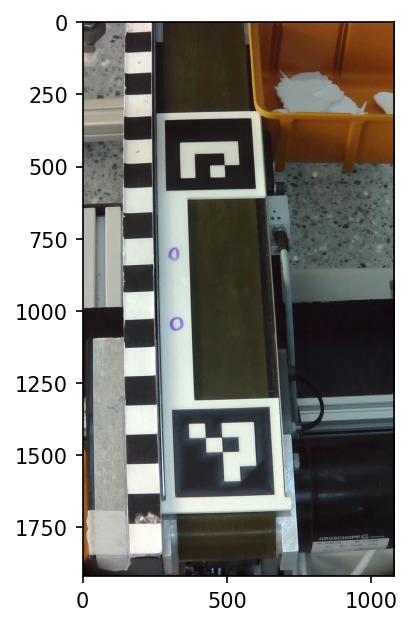

In [53]:
import cv2 as cv
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from cv2 import aruco
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 150

aruco_dict = aruco.getPredefinedDictionary(aruco.DICT_4X4_100)
parameters = aruco.DetectorParameters()
detector = aruco.ArucoDetector(aruco_dict, parameters)

img_aruco = cv.imread('aruco_pic/foto_0.png')
img_aruco_rotated = cv.rotate(img_aruco,2)

# Test Bild
img_obj = cv.imread('obj/cat/foto_10.png')
img_obj_rotated = cv.rotate(img_obj,2)

SRC_COORDS = (np.array([[[ 0.,  0.],  [60., 0.],   [60., 60.],  [ 0.,60.], 
                                [ 0., 222.], [60., 222.], [60., 282.], [ 0., 282.]]], dtype= np.float32))

plt.imshow(img_aruco_rotated)

# Bildauschnitt errechnen und segmentierung einstellen

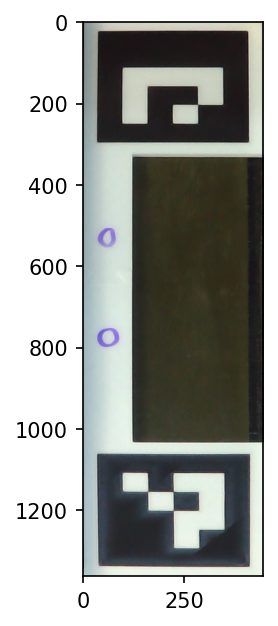

In [54]:
corners, ids, rejected = detector.detectMarkers(img_aruco_rotated)

dstPoints = np.concatenate(corners, axis=1)
H, _ = cv.findHomography(srcPoints=SRC_COORDS, dstPoints=dstPoints, method=0)
H_inv = np.linalg.inv(H)

pts1 = np.float32([
    corners[1][0][0],  # oben-links
    corners[1][0][1],  # oben-rechts
    corners[0][0][3],  # unten-links
    corners[0][0][2],  # unten-rechts
])

pts1_reshaped = pts1.astype(np.float32).reshape(-1, 1, 2)

# Pixel in Bild zu welt
world_frame = cv.perspectiveTransform(pts1_reshaped, H_inv)

# versatz - mit X und Y Offsets
offset_raw = np.array([
    [-6, +6],  # mm - X offset -6, Y offset -6
    [+6, +6],  # mm - X offset +6, Y offset -6
    [-6, -6],  # mm - X offset -6, Y offset +6
    [+6, -6]   # mm - X offset +6, Y offset +6
], dtype=np.float32)

offset = offset_raw.reshape(-1, 1, 2)
pts1_2 = world_frame + offset

pts1_2_pixel = cv.perspectiveTransform(pts1_2, H)

min_x = np.min(pts1_2_pixel[:, 0, 0])
max_x = np.max(pts1_2_pixel[:, 0, 0])
min_y = np.min(pts1_2_pixel[:, 0, 1])
max_y = np.max(pts1_2_pixel[:, 0, 1])

width = int(max_x - min_x)
height = int(max_y - min_y)

pts2_proportional = np.float32([
    [0, 0],
    [width, 0],
    [0, height],
    [width, height]
])
M_for_all = cv.getPerspectiveTransform(pts1_2_pixel, pts2_proportional)

img_warped = cv.warpPerspective(img_aruco_rotated, M_for_all, (width, height))
plt.imshow(img_warped)

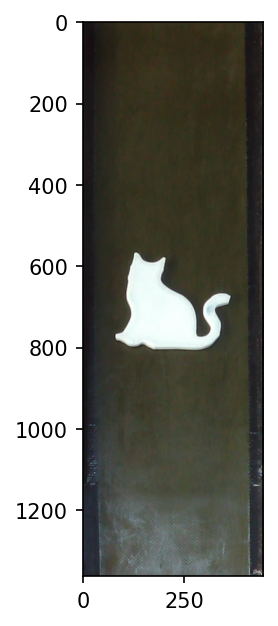

In [55]:
dst_obj = cv.warpPerspective(img_obj_rotated, M_for_all, (width, height))
plt.imshow(dst_obj)

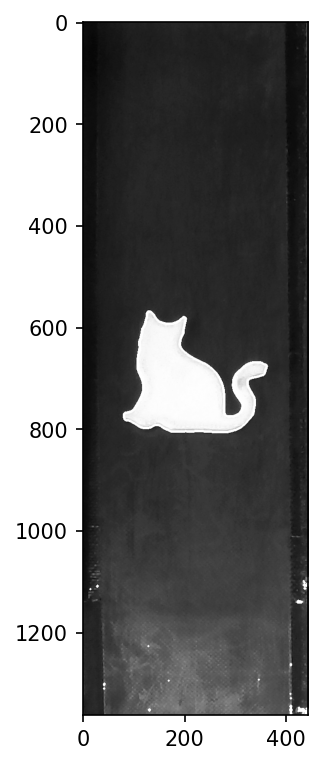

In [56]:
gray_image = cv.cvtColor(dst_obj, cv.COLOR_BGR2GRAY)

ret , img_thresh = cv.threshold(gray_image, 150, 255,cv.THRESH_BINARY + cv.THRESH_OTSU)

uint8_img_thresh = img_thresh.astype(np.uint8)

contours , hierarchy = cv.findContours(uint8_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_NONE)

img_with_contours = gray_image.copy()

cv.drawContours(img_with_contours, contours, contourIdx= -1 , color= (255, 255, 255),thickness=3)

plt.figure(figsize=(8, 6))
plt.imshow(img_with_contours, cmap='gray')

In [57]:
cwd = Path.cwd()

# Prefer local notebook directory if the notebook is already running from misc/prepWork/dev_pictures.
# Otherwise resolve from the repository root.
candidate_paths = [
    cwd / "obj",
    cwd / "misc" / "prepWork" / "dev_pictures" / "obj",
    cwd / "dev_pictures" / "obj",
]

for path in candidate_paths:
    if path.exists():
        DATA_PATH = path
        break
else:
    raise FileNotFoundError(
        f"DATA_PATH not found. Checked: {candidate_paths} (cwd={cwd})"
    )

print("Using DATA_PATH:", DATA_PATH)



Using DATA_PATH: /home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/misc/prepWork/dev_pictures/obj


In [58]:
def warp_image(img):

    img_rotated = cv.rotate(img,2)

    dst_obj = cv.warpPerspective(img_rotated, M_for_all, (width, height))
    return dst_obj

def rotate_image(img, angle):
    h, w = img.shape[:2]
    center = (w // 2, h // 2)

    M = cv.getRotationMatrix2D(center, angle, 1.0)

    return cv.warpAffine(
        img,
        M,
        (w, h),
        flags=cv.INTER_LINEAR,
        borderValue=(255, 255, 255)
    )


def mirror_image(img):
    return cv.flip(img, 1)

In [59]:
def extract_main_contour(img):

    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

    # blur = cv.GaussianBlur(gray, (5, 5), 0)

    _, thresh = cv.threshold(gray, 150, 255, cv.THRESH_BINARY)

    uint8_img_thresh = thresh.astype(np.uint8)

    contours, _ = cv.findContours(uint8_img_thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        return None

    return max(contours, key=cv.contourArea)

In [87]:
def extract_features(cnt):

    features = {}

    area = cv.contourArea(cnt)
    perimeter = cv.arcLength(cnt, True)

    if area == 0 or perimeter == 0:
        return None

    features["area"] = area
    features["perimeter"] = perimeter

    # Shape approx
    epsilon = 0.04 * perimeter
    approx = cv.approxPolyDP(cnt, epsilon, True)
    features["corners"] = len(approx)

    # Bounding box
    x, y, w, h = cv.boundingRect(cnt)

    features["aspect_ratio"] = w / h
    features["bbox_w"] = w
    features["bbox_h"] = h

    # Circularity
    features["circularity"] = (4 * np.pi * area) / (perimeter ** 2)

    # Solidity
    hull = cv.convexHull(cnt)
    hull_area = cv.contourArea(hull)

    features["solidity"] = area / hull_area if hull_area > 0 else 0

    # Hu Moments
    hu_raw = cv.HuMoments(cv.moments(cnt)).flatten()

    with np.errstate(divide="ignore"):
        hu_log = -np.sign(hu_raw) * np.log10(np.abs(hu_raw) + 1e-10)

    for i in range(7):
        features[f"hu_{i}"] = float(hu_log[i])  


    # Fourier Descriptors
    contour_pts = cnt[:, 0, :]                          # Shape: (N, 2)
    complex_contour = contour_pts[:, 0] + 1j * contour_pts[:, 1]  # Als komplexe Zahlen
    fourier = np.fft.fft(complex_contour)

    # Normalisieren: rotations-, skalierungs- und translationsinvariant
    fourier = np.abs(fourier)
    fourier /= fourier[1] if fourier[1] != 0 else 1    # Skalierungsinvarianz

    # Nur die ersten N Koeffizienten nehmen (niedrige Frequenzen = Form)
    N_DESCRIPTORS = 10
    for i in range(1, N_DESCRIPTORS + 1):
        features[f"fd_{i}"] = fourier[i] if i < len(fourier) else 0

    M_moments = cv.moments(cnt)
    features["symmetry"] = abs(M_moments["mu11"]) / (M_moments["mu20"] + M_moments["mu02"] + 1e-6)

    return features

In [88]:
angles = [0, 15, 30,45, 60,  75,90,105,120,135,150,165,170,185,200,215,230,245,260,275,290,305,320,335,350]

rows = []

In [89]:
for class_dir in DATA_PATH.iterdir():

    if not class_dir.is_dir():
        continue

    label = class_dir.name
    print("Processing:", label)

    for img_path in class_dir.glob("*.png"):

        img_first = cv.imread(str(img_path))

        img = warp_image(img_first)

        if img is None:
            continue

        # Original + augmented versions
        variants = []

        # Rotations
        for angle in angles:
            variants.append(rotate_image(img, angle))

        # Mirror + rotations
        mirrored = mirror_image(img)

        for angle in angles:
            variants.append(rotate_image(mirrored, angle))

        # Feature extraction
        for v in variants:

            cnt = extract_main_contour(v)

            if cnt is None:
                continue

            feat = extract_features(cnt)

            if feat is None:
                continue

            feat["label"] = label

            rows.append(feat)

Processing: unicorn
Processing: square
Processing: cat
Processing: circle


In [90]:
from pathlib import Path

DEBUG_PATH = Path("debug_contours")
DEBUG_PATH.mkdir(exist_ok=True)

for class_dir in DATA_PATH.iterdir():
    if not class_dir.is_dir():
        continue

    label = class_dir.name
    out_dir = DEBUG_PATH / label
    out_dir.mkdir(exist_ok=True)  # Unterordner pro Klasse

    for img_path in class_dir.glob("*.png"):

        img_first = cv.imread(str(img_path))

        img = warp_image(img_first)
        
        if img is None:
            continue

        cnt = extract_main_contour(img)

        if cnt is None:
            print(f"⚠️ Kein Contour gefunden: {img_path.name}")
            continue

        # Kontur auf Bild zeichnen
        debug_img = img.copy()
        cv.drawContours(debug_img, [cnt], -1, (0, 255, 0), 2)  # grüne Linie

        # Bounding Box dazu
        x, y, w, h = cv.boundingRect(cnt)
        cv.rectangle(debug_img, (x, y), (x+w, y+h), (255, 0, 0), 1)  # blaues Rechteck

        # Speichern
        out_path = out_dir / img_path.name
        cv.imwrite(str(out_path), debug_img)

print("✅ Debug-Bilder gespeichert unter:", DEBUG_PATH.resolve())

✅ Debug-Bilder gespeichert unter: /home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/misc/prepWork/dev_pictures/debug_contours


In [91]:
df = pd.DataFrame(rows)

print("Dataset shape:", df.shape)

df.to_csv("features_dataset.csv", index=False)

df.head()

Dataset shape: (28600, 27)


,area,perimeter,corners,aspect_ratio,bbox_w,bbox_h,circularity,solidity,hu_0,hu_1,...,fd_3,fd_4,fd_5,fd_6,fd_7,fd_8,fd_9,fd_10,symmetry,label
0,37416.0,1084.832601,7,0.932836,250,268,0.399523,0.768414,0.741609,4.545854,...,1.250666,2.365656,1.118760,0.058854,0.055709,0.042578,0.204730,0.459759,0.011971,unicorn
1,56318.0,1544.073156,3,0.269231,175,650,0.296839,0.994113,0.352649,0.795693,...,0.330605,0.246673,0.196149,0.163196,0.139111,0.121089,0.107225,0.096015,0.125133,unicorn
2,110985.0,1746.288447,3,0.578100,359,621,0.457343,0.996937,0.590893,1.541216,...,0.329956,0.246000,0.196040,0.162309,0.138357,0.120385,0.106562,0.095298,0.216593,unicorn
3,162362.0,1803.082410,4,0.753820,444,589,0.627571,0.998647,0.688882,2.065680,...,0.679987,1.950222,2.952639,5.213877,5.364735,0.000000,0.000000,0.000000,0.216070,unicorn
4,216585.5,2665.692555,6,0.555695,444,799,0.383018,0.816333,0.607082,1.713954,...,0.257310,0.070097,0.083192,0.057959,0.076894,0.038745,0.035817,0.046069,0.195744,unicorn


/home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/.venv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [15] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/.venv/lib/python3.10/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


         feature     f_score        p_value
2        corners  367.587766  2.852594e-234
7       solidity  348.643027  2.181271e-222
1      perimeter  222.554734  9.886938e-143
16          fd_2  113.372541   5.579939e-73
18          fd_4  110.998161   1.865912e-71
22          fd_8   72.727510   7.477928e-47
6    circularity   72.155563   1.745321e-46
24         fd_10   71.853712   2.729882e-46
19          fd_5   69.017213   1.827274e-44
23          fd_9   67.247201   2.518448e-43
20          fd_6   59.798667   1.571223e-38
21          fd_7   45.926065   1.340618e-29
4         bbox_w   44.250420   1.606329e-28
3   aspect_ratio   22.920099   8.186452e-15
10          hu_2   20.253898   4.169151e-13
11          hu_3   19.878840   7.243377e-13
0           area   11.601705   1.352848e-07
8           hu_0   10.157738   1.105696e-06
25      symmetry   10.074714   1.247356e-06
5         bbox_h    6.384621   2.548205e-04
17          fd_3    5.711547   6.645979e-04
13          hu_5    4.516571   3

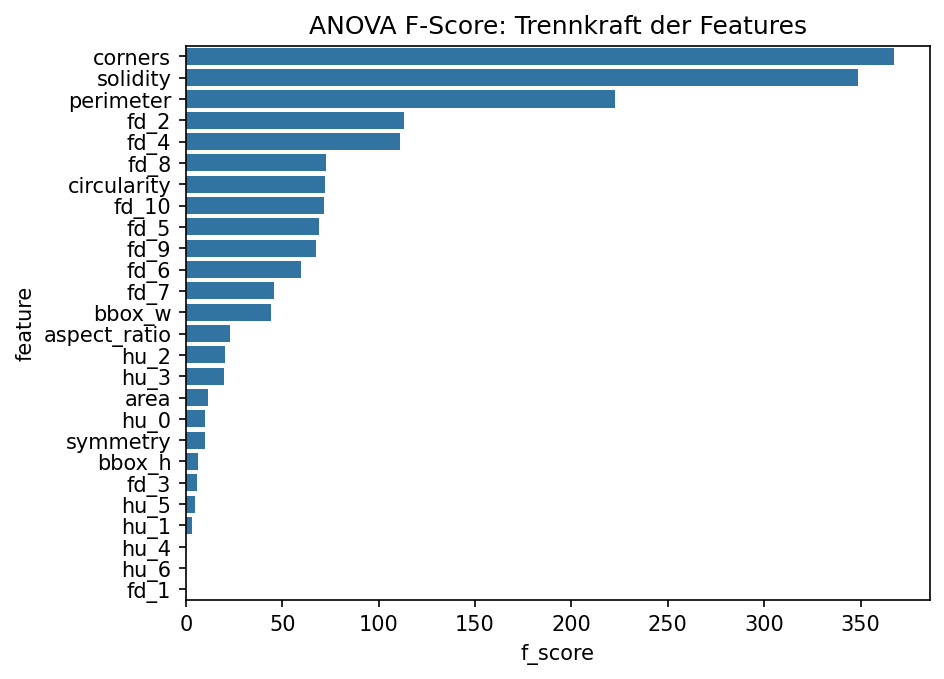

In [92]:
from sklearn.feature_selection import f_classif

X = df.drop(columns=["label"])
y = df["label"]

f_scores, p_values = f_classif(X, y)

importance_df = pd.DataFrame({
    "feature": X.columns,
    "f_score": f_scores,
    "p_value": p_values
}).sort_values("f_score", ascending=False)

print(importance_df)

# Als Plot
sns.barplot(data=importance_df, x="f_score", y="feature")
plt.title("ANOVA F-Score: Trennkraft der Features")
plt.show()

In [93]:
selected_features = [ "corners", "fd_4","perimeter",  "circularity",    "hu_4",  "fd_2","bbox_w",  "fd_3",  "fd_5",  "hu_1","solidity","fd_7",  "fd_6", "hu_0", "hu_2", "hu_3","hu_5","hu_6", "fd_1", "area" 
 ]  # 
#  

X = df[selected_features]  # use the selected feature columns
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


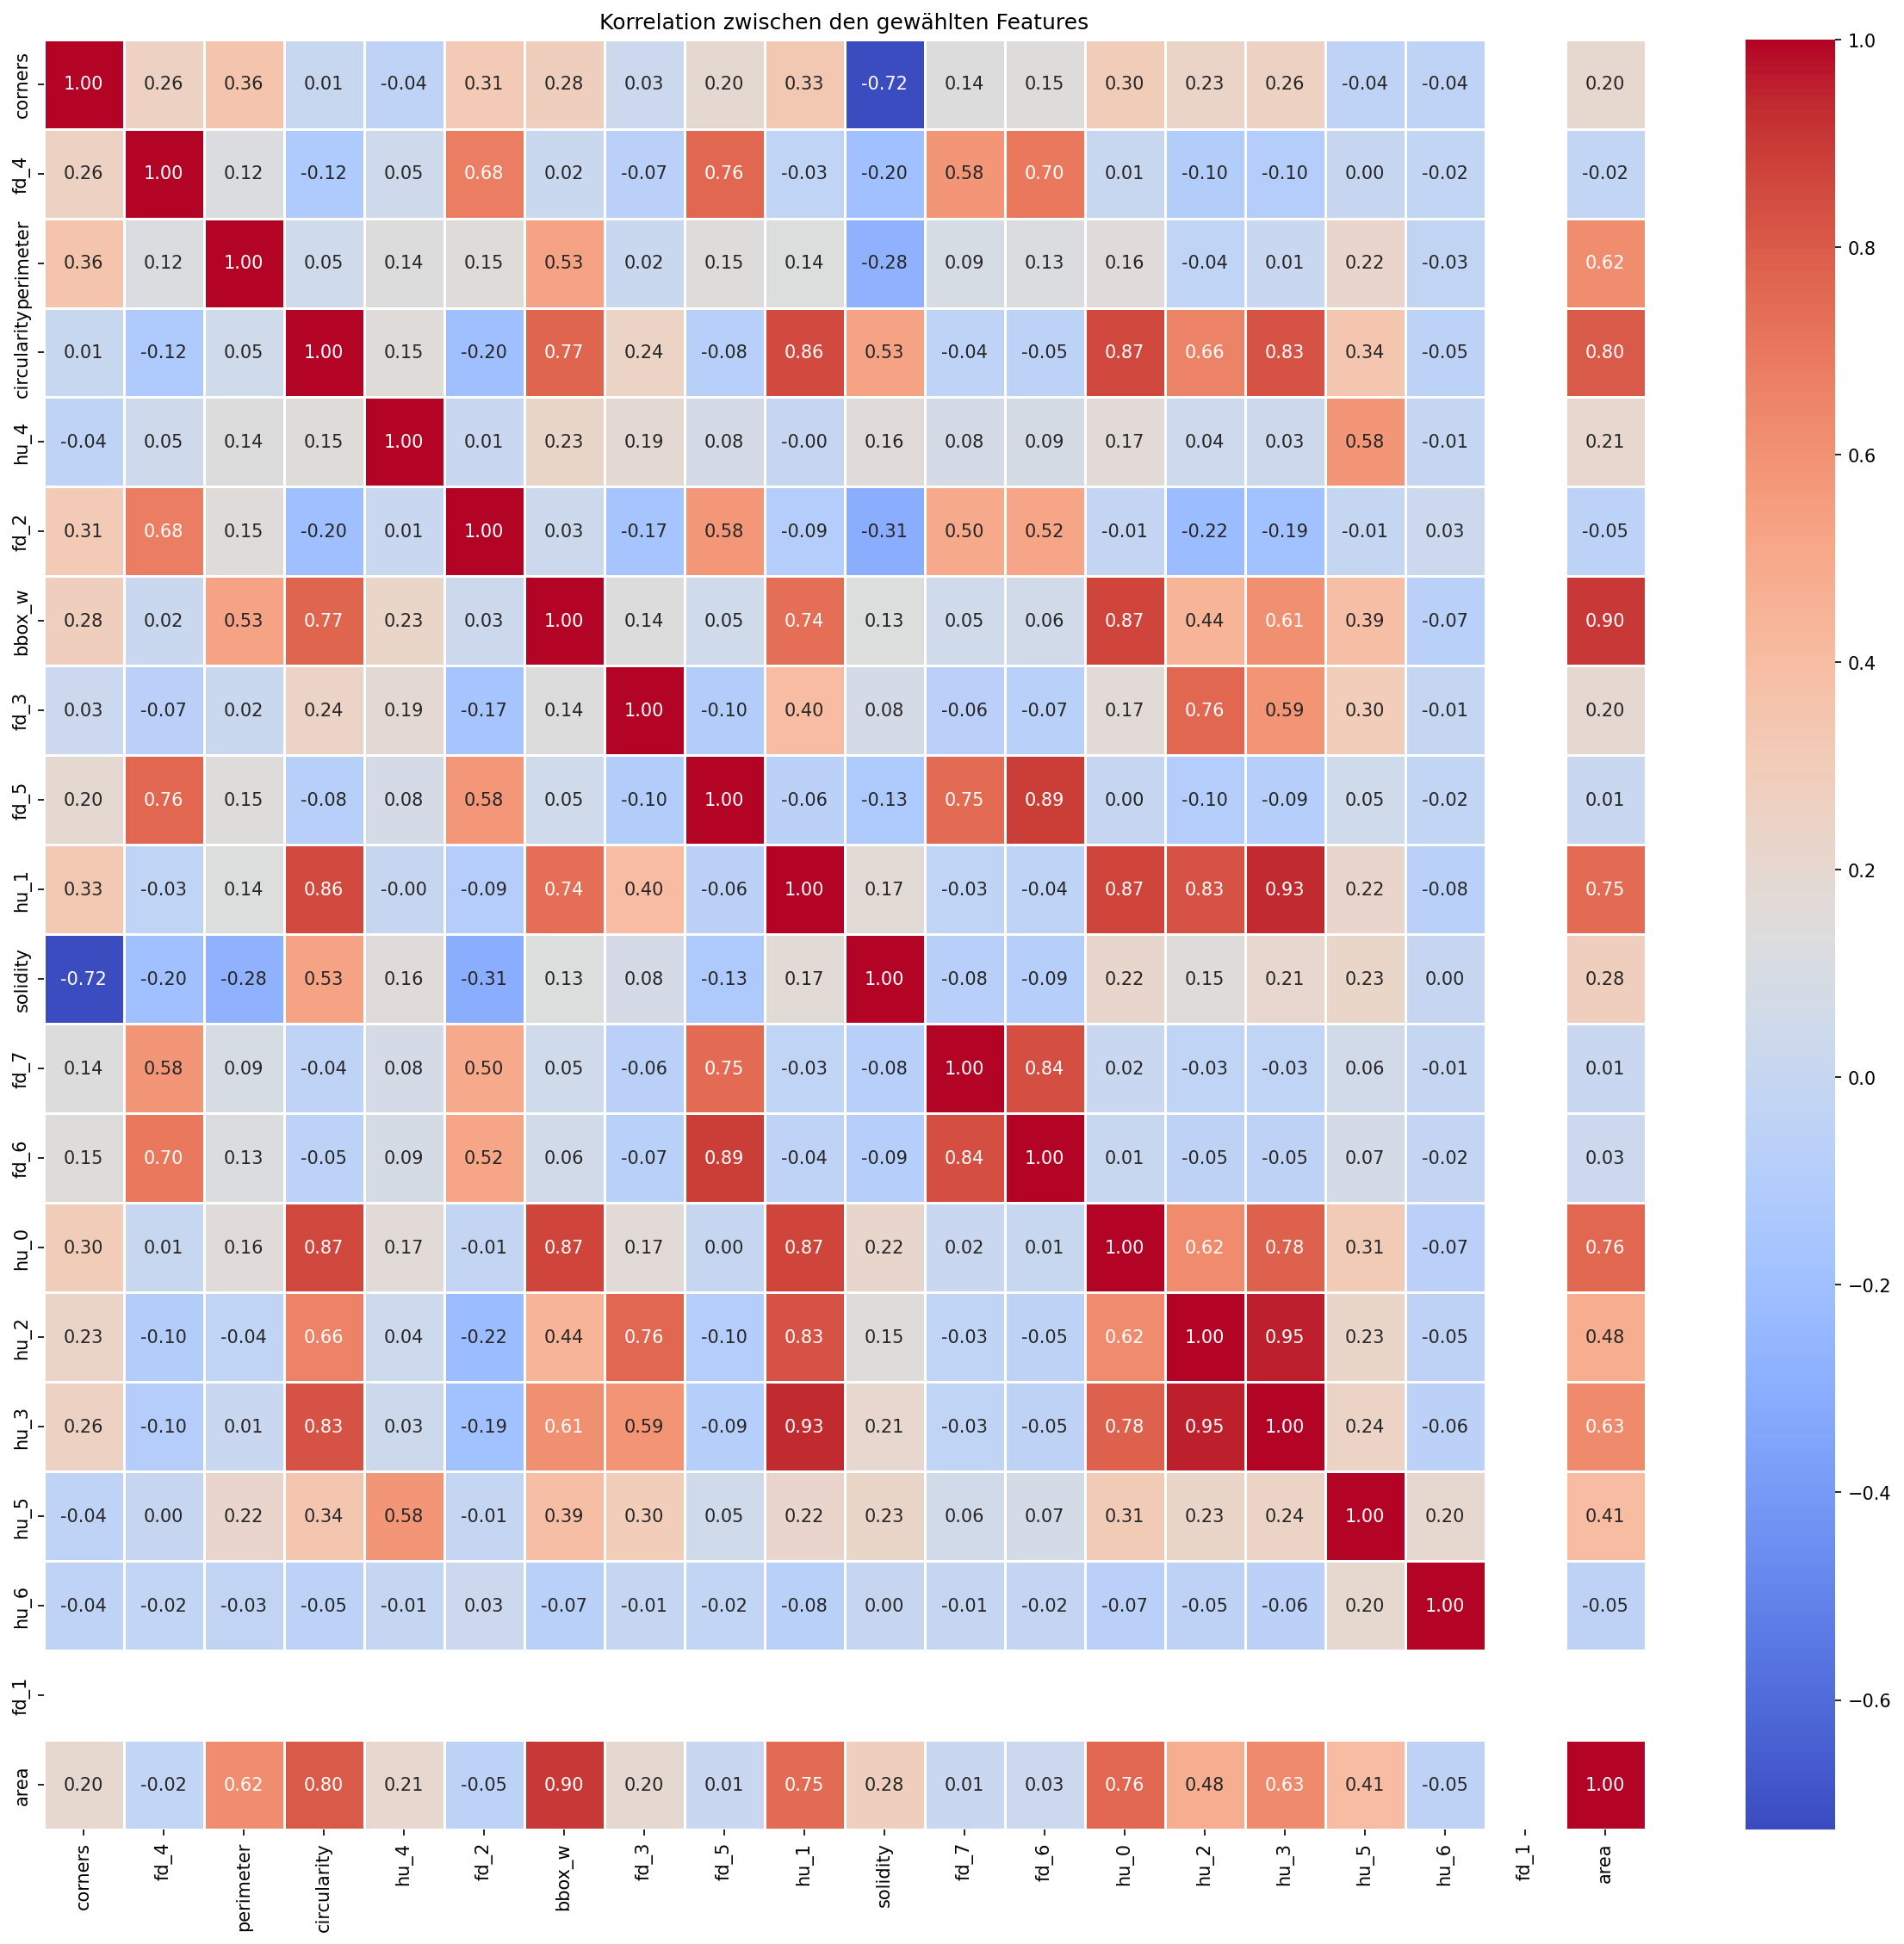

In [94]:
corr = df[selected_features].corr()

plt.figure(figsize=(20, 18))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Korrelation zwischen den gewählten Features")
plt.show()

In [95]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=31
)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [96]:
pred = model.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

         cat       0.74      0.54      0.62      2060
      circle       0.73      0.59      0.65       620
      square       0.53      0.58      0.56      1030
     unicorn       0.57      0.73      0.64      2010

    accuracy                           0.62      5720
   macro avg       0.64      0.61      0.62      5720
weighted avg       0.64      0.62      0.62      5720



In [97]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring="f1_macro")
print(f"CV F1: {scores.mean():.3f} ± {scores.std():.3f}")

CV F1: 0.642 ± 0.018


In [98]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 8, 10, 15],
    "min_samples_leaf": [1, 2, 3, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42),
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

grid.fit(X_train, y_train)
print("Beste Parameter:", grid.best_params_)
print("Bester Score:", grid.best_score_)

Beste Parameter: {'max_depth': 15, 'min_samples_leaf': 1, 'n_estimators': 300}
Bester Score: 0.7041565471219854


In [99]:
from sklearn.feature_selection import SelectFromModel

# Bestes Modell aus GridSearch
best_model = grid.best_estimator_

# Selector trainieren
selector = SelectFromModel(best_model, threshold="median", prefit=True)

# Features filtern
X_train_sel = selector.transform(X_train)
X_test_sel = selector.transform(X_test)

# Welche Features wurden gewählt?
selected_mask = selector.get_support()
selected_names = list(X.columns[selected_mask])
print(f"Features vorher: {X_train.shape[1]}")
print(f"Features nachher: {X_train_sel.shape[1]}")
print(f"Gewählte Features: {selected_names}")

Features vorher: 20
Features nachher: 10
Gewählte Features: ['perimeter', 'circularity', 'hu_1', 'solidity', 'hu_0', 'hu_2', 'hu_3', 'hu_5', 'hu_6', 'area']


/home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
/home/lbraun/Robotik/4_Semester/robotik_projekt_3/Portal-zur-Exmatrikulation/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


In [100]:
# Neues Modell mit den selektierten Features
model_final = RandomForestClassifier(
    **grid.best_params_,
    class_weight="balanced",
    random_state=42
)

model_final.fit(X_train_sel, y_train)
pred_final = model_final.predict(X_test_sel)
print(classification_report(y_test, pred_final))

              precision    recall  f1-score   support

         cat       0.72      0.66      0.69      2060
      circle       0.71      0.71      0.71       620
      square       0.78      0.60      0.68      1030
     unicorn       0.65      0.77      0.70      2010

    accuracy                           0.69      5720
   macro avg       0.71      0.69      0.69      5720
weighted avg       0.70      0.69      0.69      5720



In [101]:
joblib.dump({
    "model": model_final,
    "selector": selector,
    "selected_features": selected_names,
    "all_features": list(X.columns)
}, "random_forest_model.pkl")
print("Model saved.")

Model saved.


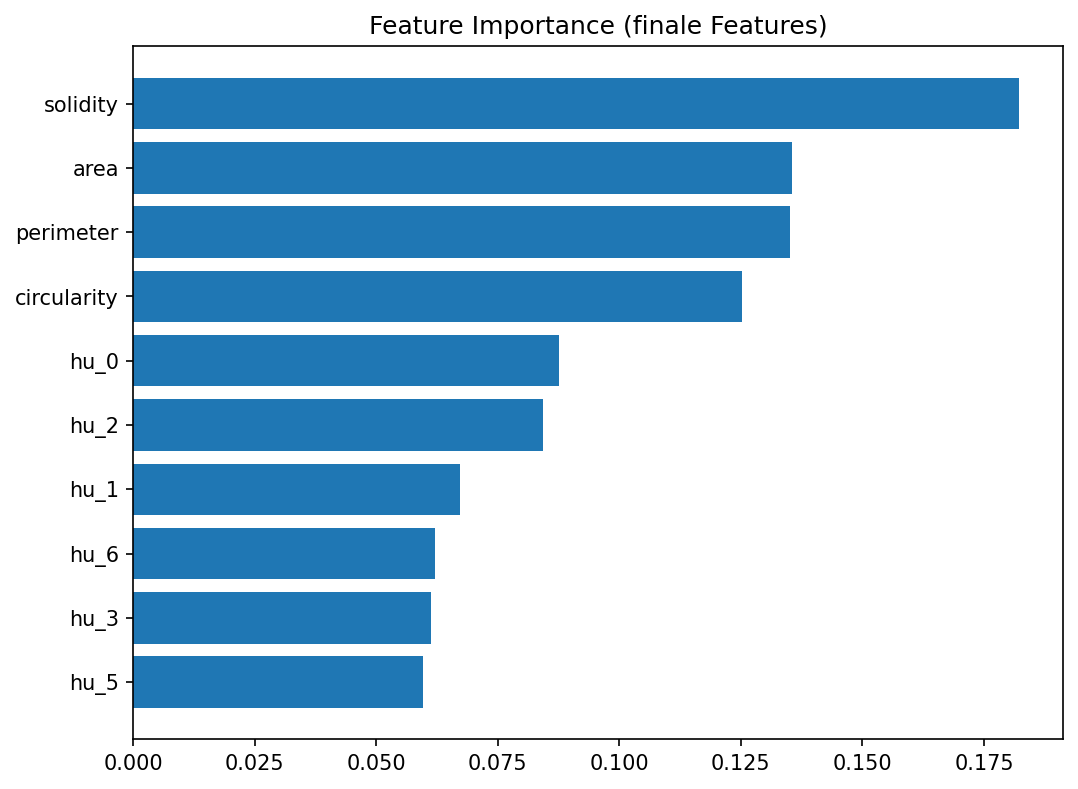

In [102]:
importances = model_final.feature_importances_  # ← model_final!
names = selected_names

idx = np.argsort(importances)

plt.figure(figsize=(8, 6))
plt.barh(np.array(names)[idx], importances[idx])
plt.title("Feature Importance (finale Features)")
plt.show()